# Seller Churn Analysis — Exploratory Data Analysis (EDA)

## Sprint 1
Цель: изучение данных, первичная очистка, визуализация и формирование гипотез для анализа churn sellers.

## Импорт библиотек
Подключаем библиотеки для анализа и визуализации данных.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
sellers = pd.read_csv(
    "../data/raw/sellers.csv",
    sep=";"
)

sku_catalog = pd.read_csv(
    "../data/raw/sku_catalog.csv",
    sep=";"
)

In [24]:
sku_daily = pd.read_csv(
    "../data/raw/sku_daily_metrics.csv",
    sep=";",
    nrows=100000
)

## Преобразование дат
Преобразуем текстовые колонки с датами в datetime формат.

In [33]:
sellers["seller_registration_dt"] = pd.to_datetime(
    sellers["seller_registration_dt"]
)

sellers["seller_first_sale_dt"] = pd.to_datetime(
    sellers["seller_first_sale_dt"]
)

## Типы данных и структура таблицы
Изучаем количество строк, колонок и типы данных.

In [34]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   seller_id                  3000 non-null   int64         
 1   seller_registration_dt     3000 non-null   datetime64[ns]
 2   seller_first_sale_dt       2992 non-null   datetime64[ns]
 3   seller_main_category       3000 non-null   object        
 4   seller_region_cluster      3000 non-null   object        
 5   seller_size_bucket         3000 non-null   object        
 6   fulfillment_model          3000 non-null   object        
 7   seller_manager_region      3000 non-null   object        
 8   seller_onboarding_channel  3000 non-null   object        
 9   seller_has_logo_flag       3000 non-null   int64         
dtypes: datetime64[ns](2), int64(2), object(6)
memory usage: 234.5+ KB


In [35]:
sellers[[
    "seller_registration_dt",
    "seller_first_sale_dt"
]].head()

,seller_registration_dt,seller_first_sale_dt
0,2024-07-15,2024-08-16
1,2025-12-15,2026-01-11
2,2025-03-06,2025-03-28
3,2024-02-20,2024-04-04
4,2024-03-12,2024-04-24


## Первичный просмотр данных
Проверяем структуру таблицы sellers и первые записи.

In [11]:
sellers.head()

,seller_id,seller_registration_dt,seller_first_sale_dt,seller_main_category,seller_region_cluster,seller_size_bucket,fulfillment_model,seller_manager_region,seller_onboarding_channel,seller_has_logo_flag
0,100001,2024-07-15,2024-08-16,Дом,Санкт-Петербург,micro,mixed,north,offline_event,1
1,100002,2025-12-15,2026-01-11,Спорт,Юг,medium,mixed,center,referral,1
2,100003,2025-03-06,2025-03-28,Обувь,Центр,small,FBO,east,partner,1
3,100004,2024-02-20,2024-04-04,Электроника,Урал,small,FBO,center,organic,1
4,100005,2024-03-12,2024-04-24,Детские товары,Урал,micro,FBO,south,organic,1


Размер таблицы

In [36]:
sellers.shape

(3000, 10)

## Проверка пропущенных значений
Анализируем наличие пропусков в данных.

In [13]:
sellers.isnull().sum()

seller_id                    0
seller_registration_dt       0
seller_first_sale_dt         8
seller_main_category         0
seller_region_cluster        0
seller_size_bucket           0
fulfillment_model            0
seller_manager_region        0
seller_onboarding_channel    0
seller_has_logo_flag         0
dtype: int64

### Вывод
В таблице практически отсутствуют пропущенные значения.
Только в колонке seller_first_sale_dt обнаружено 8 пропусков.
Это может означать отсутствие первой продажи у части селлеров.

In [14]:
sellers.columns

Index(['seller_id', 'seller_registration_dt', 'seller_first_sale_dt',
       'seller_main_category', 'seller_region_cluster', 'seller_size_bucket',
       'fulfillment_model', 'seller_manager_region',
       'seller_onboarding_channel', 'seller_has_logo_flag'],
      dtype='object')

## Анализ размера бизнеса селлеров
Изучаем распределение sellers по размеру бизнеса.

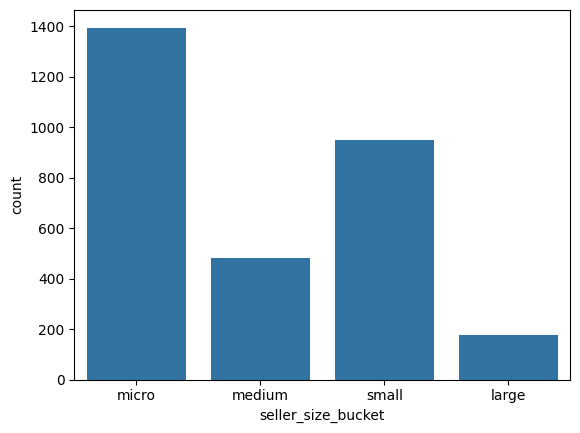

In [15]:
sns.countplot(
    data=sellers,
    x="seller_size_bucket"
)

plt.show()

### Вывод:
Большинство селлеров относятся к сегментам micro и small.
Крупных продавцов значительно меньше.

Анализ категорий

In [19]:
sellers["seller_main_category"].value_counts()

seller_main_category
Одежда                 693
Дом                    432
Красота                385
Обувь                  288
Электроника            263
Детские товары         232
Спорт                  200
Товары для животных    191
Аксессуары             179
Канцелярия             137
Name: count, dtype: int64

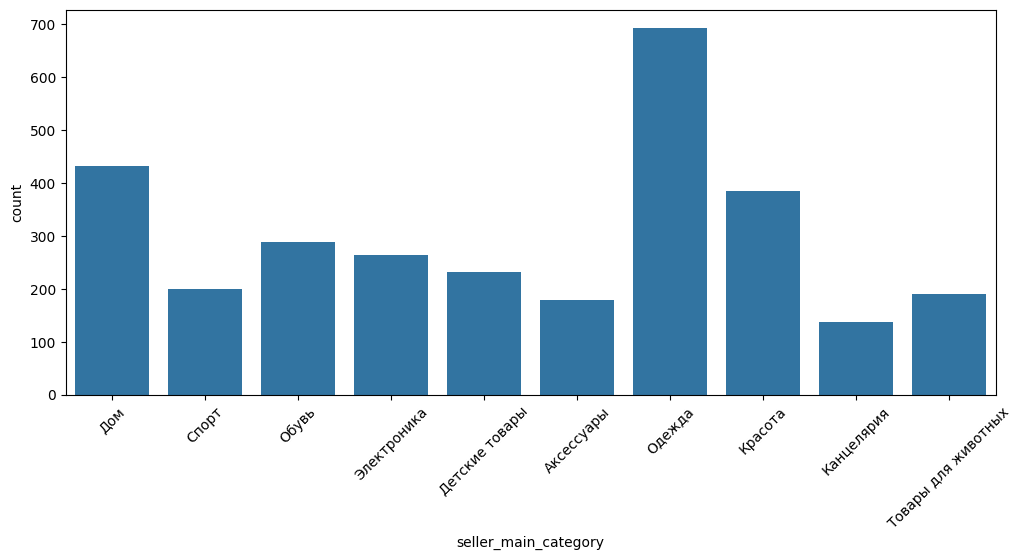

In [20]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=sellers,
    x="seller_main_category"
)

plt.xticks(rotation=45)
plt.show()

### Вывод:
Наиболее популярной категорией является «Одежда».
Большая часть селлеров сосредоточена в нескольких ключевых категориях.
Это может влиять на churn и конкуренцию внутри категорий.

## Анализ модели логистики

In [21]:
sellers["fulfillment_model"].value_counts()

fulfillment_model
FBO      1300
FBS      1169
mixed     531
Name: count, dtype: int64

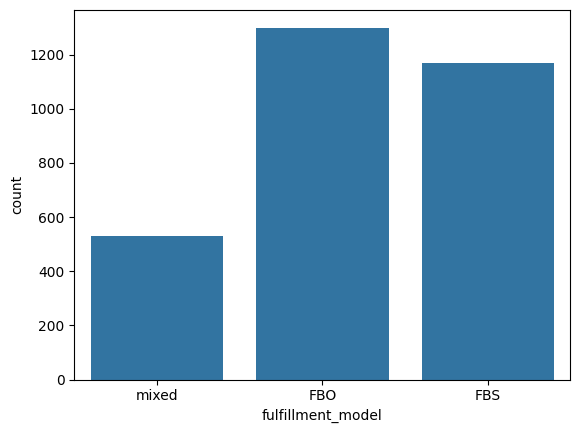

In [22]:
sns.countplot(
    data=sellers,
    x="fulfillment_model"
)

plt.show()

### Вывод
Большинство sellers используют модели FBO и FBS.
Модель mixed встречается значительно реже.
Тип fulfillment может влиять на удержание sellers и их активность.

## Анализ регионов селлеров
Изучаем распределение селлеров по регионам.

In [27]:
sellers["seller_region_cluster"].value_counts()

seller_region_cluster
Москва и МО        706
Центр              495
Поволжье           426
Юг                 362
Урал               317
Санкт-Петербург    296
Сибирь             291
Дальний Восток     107
Name: count, dtype: int64

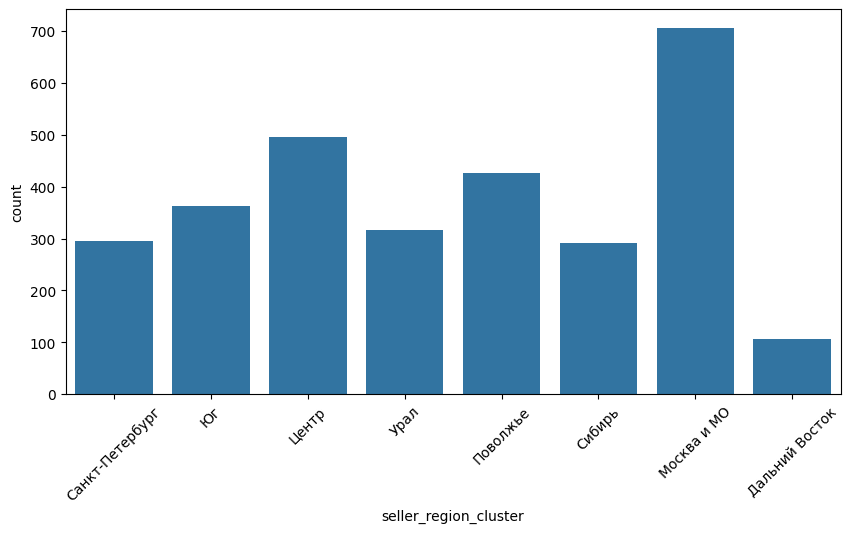

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=sellers,
    x="seller_region_cluster"
)

plt.xticks(rotation=45)
plt.show()

### Вывод
Селлеры распределены по нескольким региональным кластерам.
Наибольшая концентрация наблюдается в Москве и МО.
Минимальное количество sellers представлено в регионе Дальний Восток.

## Проверка дубликатов

In [29]:
sellers.duplicated().sum()

np.int64(0)

### Вывод
Явных дубликатов в таблице sellers не обнаружено.

## Описательная статистика

Изучаем основные статистические характеристики данных.

In [30]:
sellers.describe(include="all")

,seller_id,seller_registration_dt,seller_first_sale_dt,seller_main_category,seller_region_cluster,seller_size_bucket,fulfillment_model,seller_manager_region,seller_onboarding_channel,seller_has_logo_flag
count,3000.000000,3000,2992,3000,3000,3000,3000,3000,3000,3000.000000
unique,NaN,NaN,NaN,10,8,4,3,5,5,NaN
top,NaN,NaN,NaN,Одежда,Москва и МО,micro,FBO,center,organic,NaN
freq,NaN,NaN,NaN,693,706,1394,1300,888,1237,NaN
mean,101500.500000,2024-11-05 11:41:45.599999744,2024-12-03 05:11:23.422460160,NaN,NaN,NaN,NaN,NaN,NaN,0.725000
min,100001.000000,2023-07-02 00:00:00,2023-07-08 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,100750.750000,2024-02-25 00:00:00,2024-03-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,101500.500000,2024-11-04 12:00:00,2024-12-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
75%,102250.250000,2025-07-10 06:00:00,2025-08-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
max,103000.000000,2026-03-17 00:00:00,2026-04-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


### Вывод
Таблица содержит как категориальные, так и временные признаки.
Большинство признаков не содержат пропусков и подходят для дальнейшего анализа churn sellers.

## Анализ каналов onboarding

In [31]:
sellers["seller_onboarding_channel"].value_counts()

seller_onboarding_channel
organic          1237
partner           543
ads               509
referral          422
offline_event     289
Name: count, dtype: int64

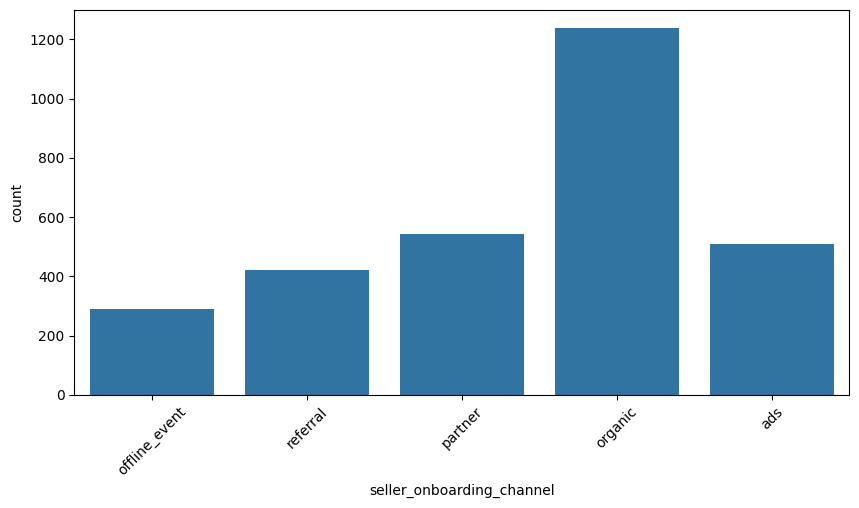

In [32]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=sellers,
    x="seller_onboarding_channel"
)

plt.xticks(rotation=45)
plt.show()

### Вывод
Наиболее популярным каналом onboarding является organic.
Также значительную долю составляют partner и ads каналы.
Канал привлечения sellers может влиять на дальнейшую активность и churn.

# Предварительные гипотезы

1. Мы предполагаем, что micro sellers имеют более высокий риск churn, так как их доля значительно выше.

2. Мы предполагаем, что sellers с низкой рекламной активностью чаще уходят с платформы.

3. Мы предполагаем, что sellers из высококонкурентных категорий чаще снижают активность.

4. Мы предполагаем, что модель fulfillment влияет на удержание sellers.

5. Мы предполагаем, что sellers без первой продажи имеют высокий риск раннего churn.

# Итоги первичного EDA

- Большинство селлеров относятся к сегментам micro и small.
- Наиболее популярная категория — Одежда.
- Основные модели fulfillment — FBO и FBS.
- Наибольшая концентрация селлеров наблюдается в Москве и МО.
- Основной onboarding channel — organic.
- В данных практически отсутствуют пропуски и дубликаты.
- Данные подходят для дальнейшего анализа churn и seller segmentation.

## Сохранение обработанных данных

In [37]:
sellers.to_csv(
    "../data/processed/sellers_clean.csv",
    index=False
)